<a href="https://colab.research.google.com/github/ahlamcod/MachineLearningAndDataScienceProjects/blob/main/emotionsNLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#0. downloading the cleaned dataset and importing necessary libraries
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
df_cleaned = pd.read_csv("/content/drive/MyDrive/airline_tweets_cleaned.csv")
display(df_cleaned.head())

Mounted at /content/drive


,text_clean,sentiment
0,VirginAmerica What dhepburn said,1
1,VirginAmerica I didnt today Must mean I need t...,1
2,VirginAmerica its really aggressive to blast o...,0
3,VirginAmerica and its a really big bad thing a...,0
4,VirginAmerica seriously would pay 30 a flight ...,0


In [ ]:
#1. Split the cleaned data into training and testing subsets using the train_test_split function, with a test size of 20% and a random state of 1.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_cleaned['text_clean'], df_cleaned['sentiment'], test_size=0.2, random_state=1)


In [ ]:
#2. Extract the text features (X) from the training and testing data, and the corresponding sentiment labels (y).
X= df_cleaned['text_clean']
y= df_cleaned['sentiment']

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
#3. Define the tokenization and stemming functions to preprocess the text data.

# Tokanization means turning phrase to list of words called tokens, example:"I am running faster than yesterday!" Tokenized → ["I", "am", "running", "faster", "than", "yesterday", "!"]
#Stemming means reducing each word to its stem, example: ["I", "am", "running", "faster", "than", "yesterday", "!"] Stemmed → ["I", "am", "run", "faster", "than", "yesterday", "!"]

import nltk
from nltk.tokenize import word_tokenize  # for splitting text into words (tokenize text)
from nltk.stem import PorterStemmer      # for stemming words to their root forms (stem words)

nltk.download('punkt') # Download the punkt tokenizer models (required for word_tokenize)

stemmer = PorterStemmer() #Initialize the stemmer

# Define a function to tokenize and stem text
def tokenize_and_stem(text):
    # Tokenize the text into individual words
    tokens = word_tokenize(text)

    # Stem each token and store in a list
    stemmed_tokens = [stemmer.stem(token) for token in tokens]

    return stemmed_tokens

# Example usage to check the function
sample_text = "I am running faster than I did yesterday!"
print("Original text:", sample_text)
print("Tokenized and stemmed:", tokenize_and_stem(sample_text))

Original text: I am running faster than I did yesterday!
Tokenized and stemmed: ['i', 'am', 'run', 'faster', 'than', 'i', 'did', 'yesterday', '!']


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
#4. Create a set of English stopwords using NLTK.
#Stopwords are words that don’t add meaning for analysis, like am, is, are, I, you, the...
#nltk provides automatic tools to create this set for English language

from nltk.corpus import stopwords #libraries necessary for stopwords set creation
import nltk

nltk.download('stopwords')

stop_words = set(stopwords.words('english')) #set creation
print(stop_words) #printing the set to verify the code

{'during', 'at', 'in', 've', 'm', 'don', 'that', "didn't", "you've", 'yourselves', 'y', 'off', "they've", "he'll", 'more', "she's", 'some', 'other', 'so', 'than', 'mustn', "he'd", 'be', 'just', 'to', 'hadn', 'too', 'been', 'for', 'he', 'there', "she'll", 'she', 'because', 'which', 'below', 's', 'haven', 'they', 'her', 'while', 'doesn', "doesn't", 'himself', 'itself', 'or', 'yourself', 'as', 'up', "we'd", 'further', "won't", 'by', 'over', "shan't", 'not', 'hasn', 'before', "mustn't", 'themselves', 'should', 'weren', "should've", 'few', "hadn't", 'does', 'doing', 'shan', 'our', 'you', 'isn', 'has', 'no', 'whom', "needn't", 'will', 'both', 'herself', 'but', 'them', 'who', 'having', 'him', "haven't", 'again', 'these', "wasn't", 'each', 'same', 'an', 'only', 'o', 'into', 'it', 'my', "they're", 'their', "we'll", 'ain', "it'd", 'me', "it's", 'how', 'above', "aren't", 'mightn', "it'll", 'on', "she'd", 'the', 'his', "that'll", 'wouldn', 't', 'now', "hasn't", "we've", "i'd", 'a', 'between', "you

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
#5. Initialize the CountVectorizer with the following configurations : Analyzer: 'word' / Tokenizer: tokenize function / Lowercase: True / ngram_range: (1, 1) / Stop words: English stopwords
#CountVectorizer is tool that turns text into numeric features for machine learning by using analyzer, tokenize, lowercase and others
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(
    analyzer='word',
    tokenizer=tokenize_and_stem, #we made it earlier
    lowercase=True, #turn any word to lower case, ex: 'Hello' becomes 'hello'
    ngram_range=(1,1), #use only single words (1-gram) and no pairs of words, ex: no 'fast running' but 2 words, 'fast' and 'run'
    stop_words=stop_words #we made it earlier
)

In [ ]:
#6. Implement StratifiedKFold cross-validation with 5 splits.
#Cross-validation is a technique to evaluate your model’s performance, instead of training once, we split data into multiple parts, train on some parts, and test on the remaining part

from sklearn.model_selection import StratifiedKFold #library for StratifiedKFold cross-validation

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) #splits your dataset into 5 folds

for fold, (train_index, test_index) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    print(f"Fold {fold}:")
    print("Train size:", len(train_index), "Test size:", len(test_index))


Fold 1:
Train size: 10841 Test size: 2711
Fold 2:
Train size: 10841 Test size: 2711
Fold 3:
Train size: 10842 Test size: 2710
Fold 4:
Train size: 10842 Test size: 2710
Fold 5:
Train size: 10842 Test size: 2710


In [ ]:
#7. Set the random seed to 1 for reproducibility.
#random seed ensures that any “random” operations (like shuffling or splitting data) produce the same results every time you run the code.

#python's random seed
import random
random.seed(1)

#numpy's random seed
import numpy as np
np.random.seed(1)

In [ ]:
#8. Build a pipeline for SVM classification, including the vectorizer and SVC with the following configurations: Probability: True / Kernel: "linear" / Class weight: "balanced"

from sklearn.pipeline import Pipeline  # Import Pipeline to chain steps, meanning instead of doing vectorization then classification separately, we can do both at once
from sklearn.svm import SVC  #Support Vector Classifier as a classification ML model
from sklearn.feature_extraction.text import CountVectorizer  # Import CountVectorizer to convert text to numeric features

pipeline = Pipeline([  # Create a pipeline combining multiple steps
    ('vectorizer', CountVectorizer()),
    ('classifier', SVC(probability=True, kernel='linear',class_weight='balanced' )) #SVC with parameters as being described in the questions
])

In [ ]:
#9. Implement the report_results function to generate performance metrics (AUC, accuracy, F1 score, precision, recall) for the best estimator on the testing data.
#to test our svc performance, we are going to implement report_results function that generates performance metrics at once

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score #importing metrics
def report_results(model, X_test, y_test): #this function is for generating performance metrics (AUC, accuracy, F1 score, precision, recall) of a certain model at once
    # Predict labels
    y_pred = model.predict(X_test)

    # Predict probabilities (needed for AUC)
    if hasattr(model, "predict_proba"):  # check if model can give probabilities
        y_prob = model.predict_proba(X_test)[:, 1]  # probability for positive class
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = "N/A"  # If model does not support probabilities

    # Calculate other metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Print metrics
    print("Model PerformanceMetrics: ")
    print(f"AUC: {auc}")
    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1 Score: {f1}")


In [ ]:
#10. Implement the get_roc_curve function to generate the ROC curve for the best estimator on the testing data.
#the goal of the get_roc_curve function is to measure how well your model separates the two classes by checking the model’s predictions at many different thresholds.
#threshold is the probability cutoff that decides whether the model predicts class 0 or class 1, if the model’s predicted probability is above the threshold → predict positive, If it is below → predict negative.Changing the threshold implies changing the model’s behavior.
from sklearn.metrics import roc_curve #importing roc_curve
def get_roc_curve(best_estimator, X_test, y_test):
    y_probs = best_estimator.predict_proba(X_test)[:, 1]
    #fpr: the fraction of negative samples that the model incorrectly predicts as positive.
    #tpr: the fraction of positive samples that the model correctly predicts as positive. Also called sensitivity or recall.
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    return fpr, tpr, thresholds

import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
def plot_roc_curve(best_estimator, X_test, y_test): #plotting roc_auc_score
    y_probs = best_estimator.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc = roc_auc_score(y_test, y_probs)
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()


In [ ]:
#11. Plot the ROC curve using matplotlib, with the false positive rate (FPR) on the x-axis and the true positive rate (TPR) on the y-axis.

#train pipeline model
pipeline.fit(X_train, y_train)

#get ROC curve values using get_roc_curve
fpr, tpr, thresholds = get_roc_curve(pipeline, X_test, y_test)
print("FPR:", fpr[:5], "...")
print("TPR:", tpr[:5], "...")
print("Thresholds:", thresholds[:5], "...")


FPR: [0.         0.         0.         0.00057307 0.00057307] ...
TPR: [0.         0.00103627 0.00414508 0.00414508 0.02279793] ...
Thresholds: [       inf 0.99998783 0.99509102 0.9946624  0.98186137] ...


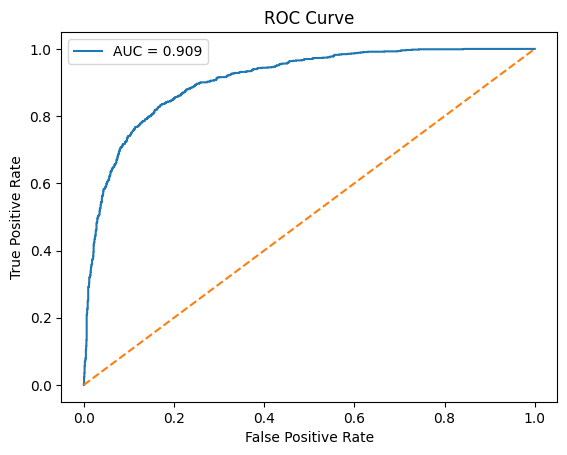

In [ ]:
#12. Display the ROC curve plot.
#plot ROC curve using plot_roc_curve
plot_roc_curve(pipeline, X_test, y_test)

In [ ]:
# Sample tweets
sample_tweet1 = ["I love this product! It's amazing."]  # clearly positive
sample_tweet2 = ["I hated it!!"]                        # short negative, outside training domain
sample_tweet3 = ["This flight was terrible."]           # short negative, matches training domain

# Predict sentiments using the trained pipeline
predicted_sentiment1 = pipeline.predict(sample_tweet1)[0]
predicted_sentiment2 = pipeline.predict(sample_tweet2)[0]
predicted_sentiment3 = pipeline.predict(sample_tweet3)[0]

# Display results
print("Tweet 1:", sample_tweet1[0])
print("Predicted sentiment:", predicted_sentiment1)  # expected 1 (positive)
print()
print("Tweet 2:", sample_tweet2[0])
print("Predicted sentiment:", predicted_sentiment2)  # predicted 1 (positive), actually negative
print()
print("Tweet 3:", sample_tweet3[0])
print("Predicted sentiment:", predicted_sentiment3)  # predicted 0 (negative)


# Analysis / Remark:
# In the case of Tweet 2 ("I hated it!!"), the model predicted a positive sentiment, which is incorrect.
# The likely reason is that our training dataset consisted of airline-related tweets (American Airlines),
# and words like "hate" or "product" were never present in the dataset. Therefore, the model did not learn
# how to classify such expressions correctly, treating it as neutral and predicting positive by default.
# This limitation is also due to using only a Support Vector Classifier (SVC). In a real-world scenario,
# as data analysts or machine learning engineers, we would compare multiple classification models
# (e.g., logistic regression, random forest, Naive Bayes) to find the best-performing model.
# The lab constrained us to use only SVC, but exploring multiple classifiers would improve predictions
# and generalization to new, unseen text

Tweet 1: I love this product! It's amazing.
Predicted sentiment: 1

Tweet 2: I hated it!!
Predicted sentiment: 1

Tweet 3: This flight was terrible.
Predicted sentiment: 0


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
import joblib

# Assuming you trained your pipeline like this
model = make_pipeline(CountVectorizer(), MultinomialNB())

# Save with joblib
joblib.dump(model, "sentiment_model.pkl")


['sentiment_model.pkl']